# Expansiones STR a escala poblacional revelan atrofia cerebral preclínica

> 1.020.833 personas escaneadas. ¿Cuántas cargan en silencio una mutación que enfermará a su cerebro?

**Paper:** [Population-scale repeat expansions elucidate disease risk and brain atrophy](https://doi.org/10.1038/s41586-026-10345-6)
**Journal:** *Nature*, 8 abril 2026 · **DOI:** [10.1038/s41586-026-10345-6](https://doi.org/10.1038/s41586-026-10345-6)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-08-repeticiones-str-atrofia-cerebral/notebook.ipynb)

**Video:** [Pendiente]

## Lo que hicieron

Hay tramos del ADN donde una secuencia corta se repite muchas veces seguidas — los STRs (*short tandem repeats*). Cuando esas repeticiones se expanden más allá de un umbral, causan más de 70 enfermedades neurológicas: Huntington, distrofia miotónica, ataxia espinocerebelosa, ELA familiar, y otras.

Hasta ahora habíamos visto STRs caso por caso, en cohortes de cientos o miles de personas. Aquí los autores buscaron 37 loci patogénicos en **más de un millón de muestras** de cinco cohortes (UK Biobank, GHS MyCode, Mayo Clinic, Penn Medicine, MCPS México) y cruzaron las longitudes de repetición con 7.671 rasgos clínicos.

El objetivo: ¿cuántas personas cargan estas expansiones sin saberlo? ¿Qué le pasa a su cerebro antes del primer síntoma?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_TOTAL_MUESTRAS = 1_020_833    # Tamaño total del estudio
N_LOCI = 37                     # Loci STR analizados
N_RASGOS_PHEWAS = 7_671         # Rasgos clínicos cruzados
FUENTE = 'Fuente: Regeneron Genetics Center et al. (2026), Nature | DOI 10.1038/s41586-026-10345-6'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#059669'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Cargar los CSVs (versiones procesadas del paper y sus tablas suplementarias)
atrofia = pd.read_csv('datos/atrofia_cerebral.csv')
phewas = pd.read_csv('datos/phewas_top.csv')
portadores = pd.read_csv('datos/portadores_vs_prevalencia.csv')
nfl = pd.read_csv('datos/nfl_fold_change.csv')

print(f'Datos cargados:')
print(f'  - atrofia_cerebral: {len(atrofia)} filas (5 regiones cerebrales)')
print(f'  - phewas_top:       {len(phewas)} asociaciones canónicas')
print(f'  - portadores:       {len(portadores)} loci con prevalencia')
print(f'  - nfl:              {len(nfl)} loci con biomarcador en sangre')

Datos cargados:
  - atrofia_cerebral: 5 filas (5 regiones cerebrales)
  - phewas_top:       6 asociaciones canónicas
  - portadores:       5 loci con prevalencia
  - nfl:              3 loci con biomarcador en sangre


## Lo más dramático del paper

Aquí está.

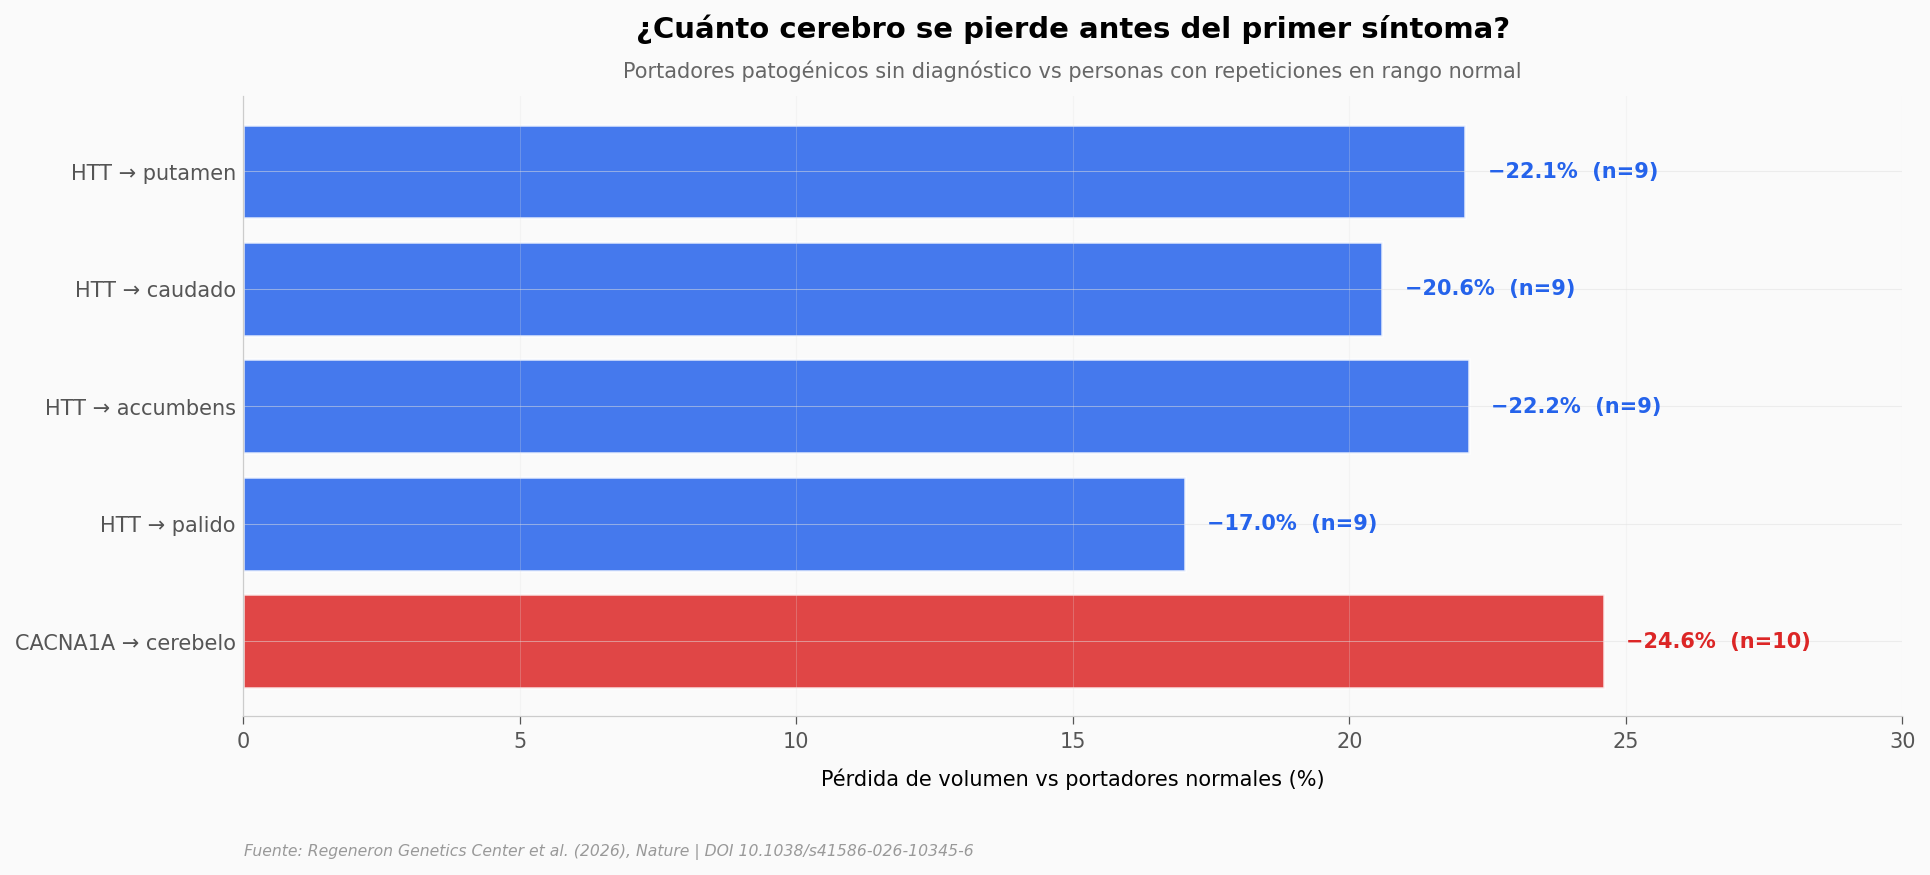

In [2]:
# Gráfica hero: pérdida de volumen cerebral en portadores patogénicos
# vs personas con repeticiones normales. Antes del diagnóstico clínico.

fig, ax = plt.subplots(figsize=(13, 5.5))

# Etiqueta combinada locus + región
labels = [f"{r['locus']} → {r['region']}" for _, r in atrofia.iterrows()]
valores = atrofia['reduccion_pct'].values
n_pat = atrofia['n_patogenicos'].values

# CACNA1A en color de alerta — el gap más grande del dataset
colors = [COLOR_ALERTA if l.startswith('CACNA1A') else COLOR_DATOS for l in labels]

y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, valores, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.2)

# Anotar valor + n al final de cada barra
for i, (val, n) in enumerate(zip(valores, n_pat)):
    ax.text(val + 0.4, i, f'−{val:.1f}%  (n={n})',
            va='center', fontsize=10, fontweight='bold',
            color=colors[i])

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Pérdida de volumen vs portadores normales (%)', fontsize=10)
ax.set_xlim(0, 30)
ax.set_title('¿Cuánto cerebro se pierde antes del primer síntoma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Portadores patogénicos sin diagnóstico vs personas con repeticiones en rango normal',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.axvline(x=0, color='#666666', linewidth=0.8)
ax.grid(axis='x', alpha=0.25)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/atrofia_cerebral.png', dpi=200, bbox_inches='tight')
plt.show()

Estas personas todavía no tienen el diagnóstico clínico de su enfermedad.

El golpe más fuerte aparece en la barra roja: en portadores de la expansión patogénica de **CACNA1A** (causante de la ataxia espinocerebelosa tipo 6), el cerebelo —la región del control fino del movimiento— aparece casi un cuarto más pequeño que en personas con repeticiones normales. En portadores de la expansión de **HTT** (Huntington), las cuatro estructuras del estriado se ven entre un 17% y un 22% más pequeñas. El estriado es justo el circuito que la enfermedad ataca primero.

La cifra que conviene fijar: el cerebro de quien carga la mutación **parece** ya estar cambiando antes de que un médico diagnostique nada. Decimos *parece* porque el estudio mira a estas personas en un solo momento — no las siguió a lo largo de los años. Una parte podría desarrollar la enfermedad pronto; otra parte podría no desarrollarla nunca por penetrancia incompleta.

Y los `n` son honestos: 9 portadores de HTT, 10 de CACNA1A. Son señales fuertes pero pequeñas en absoluto. Lo que les da peso son los `p` reportados en HTT (entre 10⁻⁸ y 10⁻¹⁸ según región) — y que el siguiente paso (validar el método) recupera enfermedades conocidas con asociaciones masivas.

## ¿Cómo sabemos que el método funciona?

Antes de creerle al hallazgo nuevo (atrofia preclínica), conviene preguntar si la técnica recupera lo que ya sabíamos. Si encuentra los enlaces canónicos —HTT con Huntington, DMPK con distrofia miotónica, C9ORF72 con ELA— con fuerza estadística enorme, gana credibilidad para el resto.

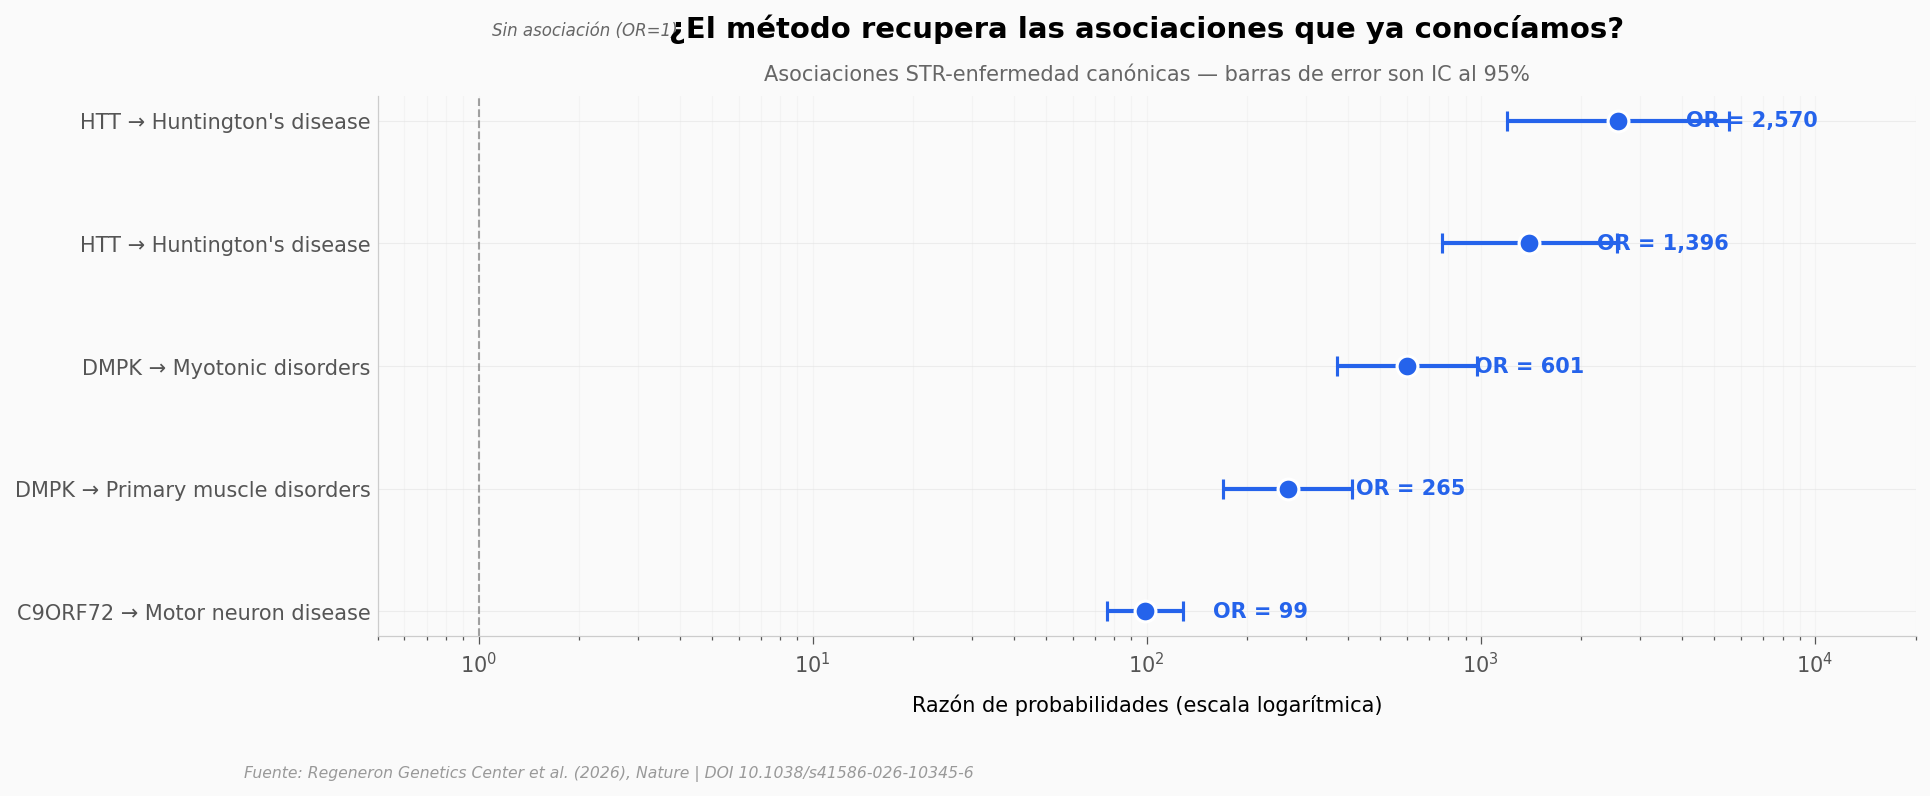

In [3]:
# PheWAS top hits — odds ratios (escala log) para asociaciones canónicas
# Filtrar las 4 con IC95% disponible

phewas_plot = phewas.dropna(subset=['OR_IC95_inf', 'OR_IC95_sup']).copy()
phewas_plot = phewas_plot.sort_values('odds_ratio', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
y_pos = np.arange(len(phewas_plot))

# Error bars asimétricos (CI inferior y superior)
or_vals = phewas_plot['odds_ratio'].values
err_inf = or_vals - phewas_plot['OR_IC95_inf'].values
err_sup = phewas_plot['OR_IC95_sup'].values - or_vals

ax.errorbar(or_vals, y_pos, xerr=[err_inf, err_sup],
            fmt='o', color=COLOR_DATOS, markersize=10,
            ecolor=COLOR_DATOS, elinewidth=2, capsize=5,
            markerfacecolor=COLOR_DATOS, markeredgecolor='white',
            markeredgewidth=1.5, zorder=5)

# Etiquetas
labels_pw = [f"{r['locus']} → {r['enfermedad']}" for _, r in phewas_plot.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_pw, fontsize=10)

# Anotar OR al lado del punto
for i, val in enumerate(or_vals):
    ax.text(val * 1.6, i, f'OR = {val:,.0f}',
            va='center', fontsize=10, fontweight='bold',
            color=COLOR_DATOS)

ax.set_xscale('log')
ax.axvline(x=1, color='#666666', linewidth=1, linestyle='--', alpha=0.6)
ax.text(1.1, len(phewas_plot) - 0.3, 'Sin asociación (OR=1)',
        fontsize=8, color='#666666', style='italic')

ax.set_xlabel('Razón de probabilidades (escala logarítmica)', fontsize=10)
ax.set_xlim(0.5, 20000)
ax.set_title('¿El método recupera las asociaciones que ya conocíamos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Asociaciones STR-enfermedad canónicas — barras de error son IC al 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.grid(axis='x', alpha=0.25, which='both')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/phewas_validacion.png', dpi=200, bbox_inches='tight')
plt.show()

## El gap entre quienes cargan y quienes están enfermos

El método recupera lo conocido con razones de probabilidades de cientos a miles. Eso da licencia para mirar el siguiente número, que es el que más sorprende: cuántos portadores de cada expansión patogénica hay en la población — comparados con cuántas personas están diagnosticadas con la enfermedad correspondiente.

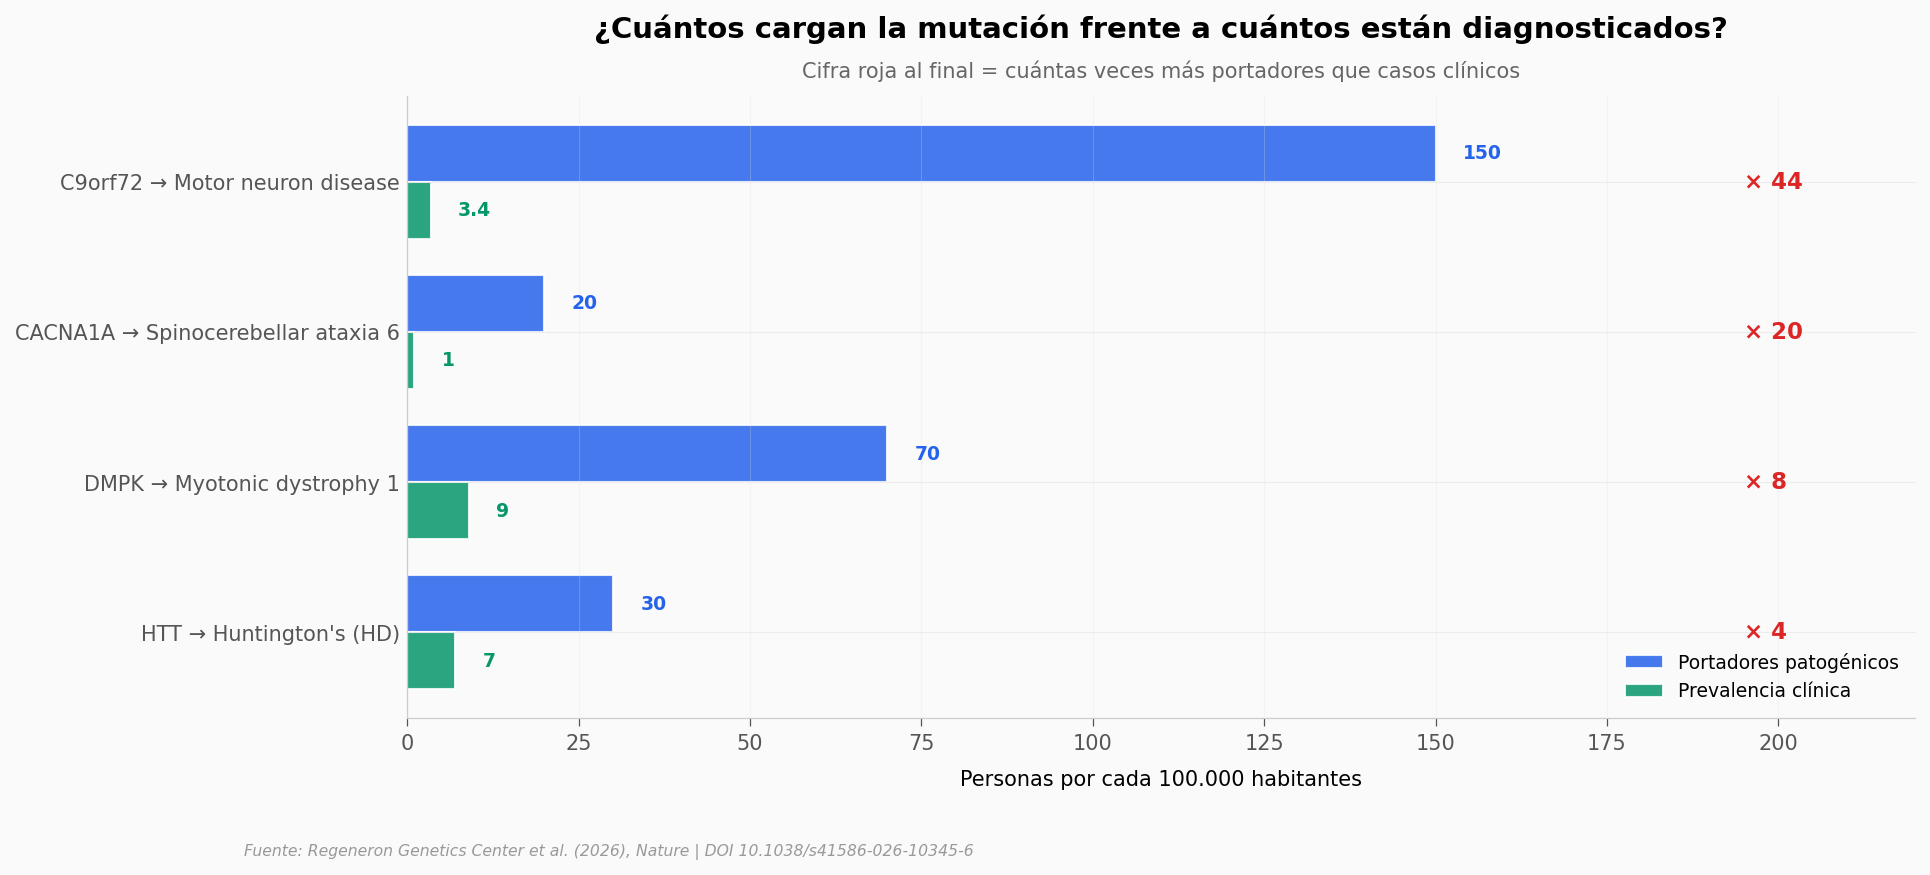

In [4]:
# Comparación: portadores patogénicos por 100.000 vs prevalencia clínica
# Gap masivo en C9orf72 (44× más portadores que casos)

# Usar pooled de DMPK donde haya WGS (más confiable según paper)
port_plot = portadores.copy()
# Quedarnos con un row por locus — DMPK WES tiene 180/100k (más alto pero menos preciso)
# Preferir WGS para DMPK (más confiable según paper); ordenar y quedarse con la última fila por locus.
port_plot = port_plot.sort_values(['locus', 'metodo_secuenciacion']).copy()
port_plot = port_plot.drop_duplicates(subset='locus', keep='last').reset_index(drop=True)

# Calcular ratio carriers/cases (usar prevalencia_max para la cota conservadora)
port_plot['ratio'] = port_plot['portadores_por_100k'] / port_plot['prevalencia_max_por_100k']
port_plot = port_plot.sort_values('ratio', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

y_pos = np.arange(len(port_plot))
height = 0.38

bars1 = ax.barh(y_pos + height/2, port_plot['portadores_por_100k'],
                height=height, color=COLOR_DATOS, alpha=0.85,
                edgecolor='white', linewidth=1, label='Portadores patogénicos')
bars2 = ax.barh(y_pos - height/2, port_plot['prevalencia_max_por_100k'],
                height=height, color=COLOR_REFERENCIA, alpha=0.85,
                edgecolor='white', linewidth=1, label='Prevalencia clínica')

# Anotar valores
for i, row in port_plot.iterrows():
    ax.text(row['portadores_por_100k'] + 4, i + height/2,
            f"{int(row['portadores_por_100k'])}",
            va='center', fontsize=9, fontweight='bold', color=COLOR_DATOS)
    prev = row['prevalencia_max_por_100k']
    ax.text(prev + 4, i - height/2,
            f"{prev:g}",
            va='center', fontsize=9, fontweight='bold', color=COLOR_REFERENCIA)
    # Ratio al final
    ax.text(195, i, f"× {row['ratio']:.0f}",
            va='center', fontsize=11, fontweight='bold', color=COLOR_ALERTA)

labels_pv = [f"{r['locus']} → {r['enfermedad']}" for _, r in port_plot.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_pv, fontsize=10)
ax.set_xlabel('Personas por cada 100.000 habitantes', fontsize=10)
ax.set_xlim(0, 220)
ax.set_title('¿Cuántos cargan la mutación frente a cuántos están diagnosticados?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cifra roja al final = cuántas veces más portadores que casos clínicos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(axis='x', alpha=0.25)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/portadores_vs_prevalencia.png', dpi=200, bbox_inches='tight')
plt.show()

La distancia entre las dos barras tiene varias explicaciones simultáneas — y todas conviven:

- **Penetrancia incompleta:** algunos portadores nunca van a desarrollar síntomas. La expansión está, la enfermedad no llega.
- **Edad de aparición tardía:** Huntington y SCA6 se manifiestan típicamente después de los 40-50 años. La cohorte UK Biobank tiene edad mediana de 58 — muchos portadores aún no han llegado a su debut clínico.
- **Subdiagnóstico:** sobre todo en distrofia miotónica, donde los síntomas tempranos son inespecíficos.
- **Falsos positivos del método:** el secuenciado short-read tiene limitaciones para llamar repeticiones largas. Los autores lo discuten.

El número que más golpea es C9orf72: 44 portadores por cada paciente diagnosticado con enfermedad de motoneurona. Eso cambia la pregunta del diagnóstico precoz: ya no es *cuántos enfermos hay*, sino *cuántos cargan el riesgo en silencio*.

## ¿Hay alguna huella de eso en sangre?

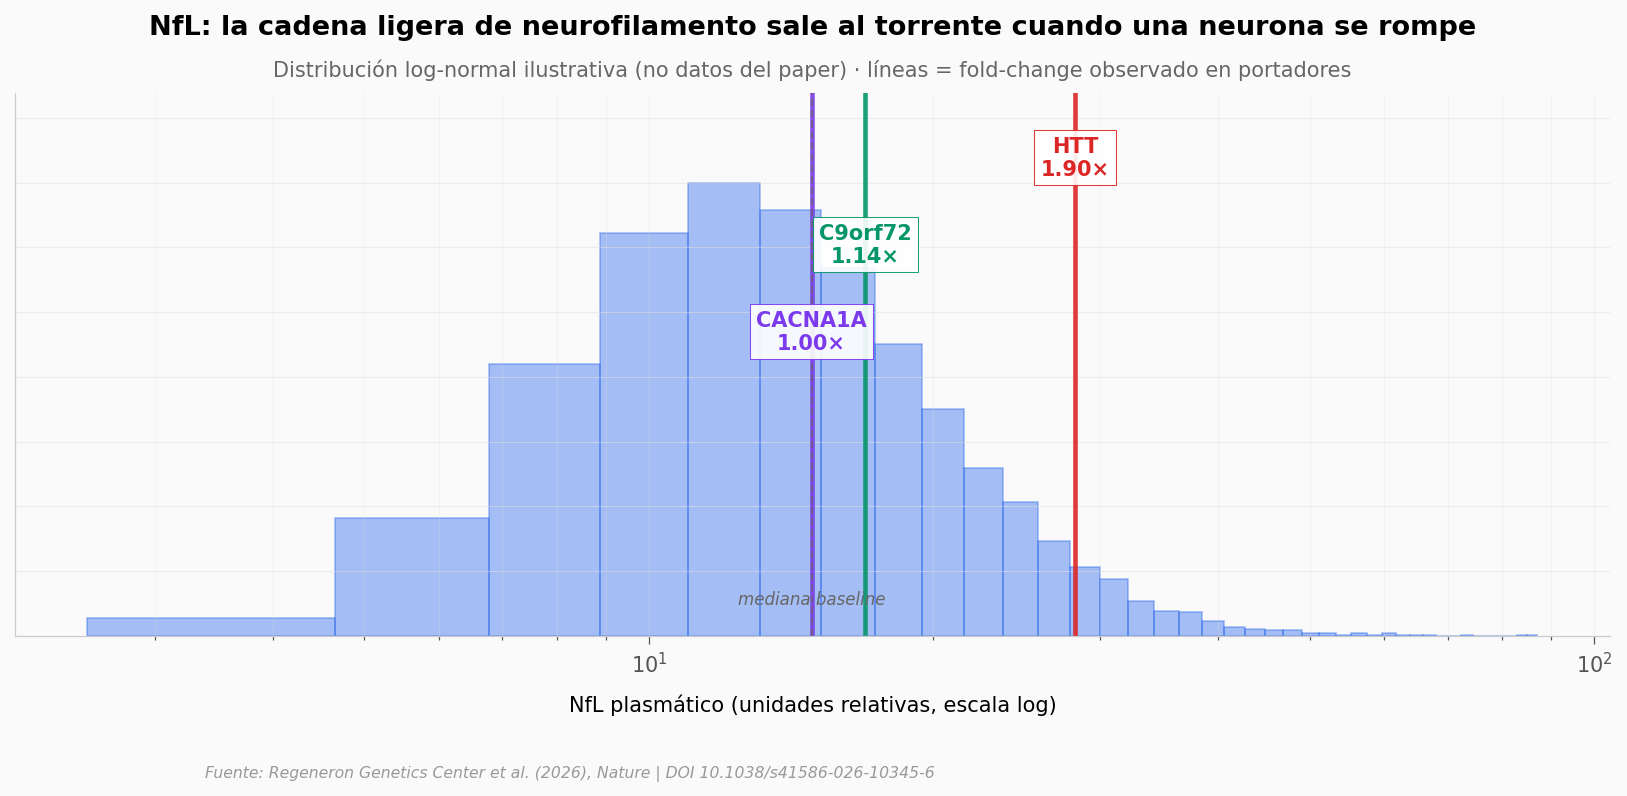


Mediana baseline NfL (simulado): 14.86
HTT (1.9×):     28.24  → p = 2.1e-12
C9orf72 (1.14×): 16.94  → p = 4.5e-3
CACNA1A (1.0×):  14.86  → no significativo


In [5]:
# Histograma simulado de NfL en no-portadores + línea vertical en HTT
# El fold-change reportado es 1.9× para HTT vs normales (p=2.1e-12)
# Generamos una distribución log-normal calibrada para mostrar dónde cae HTT

np.random.seed(42)
# NfL en personas con repeticiones normales: log-normal típico
nfl_normal = np.random.lognormal(mean=2.7, sigma=0.45, size=10000)
# Recalibrar para que la mediana represente el baseline (y luego mostrar fold-changes)
mediana = np.median(nfl_normal)

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(nfl_normal, bins=40, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Líneas verticales en cada fold-change observado
nfl_data = nfl.copy()
nfl_data['posicion'] = mediana * nfl_data['fold_change_nfl']

color_map = {'HTT': COLOR_ALERTA, 'C9orf72': COLOR_REFERENCIA, 'CACNA1A': '#7C3AED'}
y_label = y_max * 0.92
for _, row in nfl_data.iterrows():
    color = color_map[row['locus']]
    ax.axvline(x=row['posicion'], color=color, linewidth=2.2, alpha=0.9)
    significance = 'p < 0,01' if row['interpretacion'] == 'significativo' else 'no significativo'
    ax.text(row['posicion'], y_label, f"{row['locus']}\n{row['fold_change_nfl']:.2f}×",
            ha='center', va='top', fontsize=10, fontweight='bold', color=color,
            bbox=dict(facecolor='white', edgecolor=color, alpha=0.9, pad=3))
    y_label -= y_max * 0.16

# Línea de la mediana del baseline
ax.axvline(x=mediana, color='#666666', linewidth=1, linestyle='--', alpha=0.7)
ax.text(mediana, y_max * 0.05, 'mediana baseline',
        fontsize=8, color='#666666', style='italic',
        ha='center', va='bottom')

ax.set_xlabel('NfL plasmático (unidades relativas, escala log)', fontsize=10)
ax.set_xscale('log')
ax.set_yticklabels([])
ax.set_title('NfL: la cadena ligera de neurofilamento sale al torrente cuando una neurona se rompe',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución log-normal ilustrativa (no datos del paper) · líneas = fold-change observado en portadores',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='x', alpha=0.25, which='both')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/nfl_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nMediana baseline NfL (simulado): {mediana:.2f}")
print(f"HTT (1.9×):     {mediana * 1.9:.2f}  → p = 2.1e-12")
print(f"C9orf72 (1.14×): {mediana * 1.14:.2f}  → p = 4.5e-3")
print(f"CACNA1A (1.0×):  {mediana * 1.0:.2f}  → no significativo")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El estudio analizó >1 millón de muestras (1.020.833) para el screening STR | ✅ | Sub-cohorte con imagen cerebral: ~58k–63k normales según región (ver tabla atrofia) |
| HTT pathogenic se asocia con Huntington | ✅ | OR = 1.396 (IC 763–2.553), p = 3·10⁻¹²² |
| DMPK pathogenic se asocia con distrofia miotónica | ✅ | OR = 601 (IC 371–973), p = 9·10⁻¹⁴⁹ |
| C9ORF72 pathogenic se asocia con enfermedad de motoneurona | ✅ | OR = 99 (IC 76–128), p = 4·10⁻¹¹¹ |
| Portadores HTT pierden 22.1% de volumen del putamen | ⚠️ | n=9 portadores vs n=58.792 normales · p = 1.4·10⁻¹⁸ — señal estadística fuerte pero muestra muy chica · sin SD por grupo en datos suplementarios, no se puede calcular Cohen's d |
| Portadores CACNA1A pierden 24.6% de volumen del cerebelo | ⚠️ | n=10 portadores vs n=62.938 normales · p no reportado en datos suplementarios disponibles · misma limitación de muestra; sin SD por grupo no hay Cohen's d |
| Hay 44× más portadores de C9orf72 que casos diagnosticados | ⚠️ | 150/100k vs 3.4/100k. Limitación: penetrancia incompleta + edad + subdiagnóstico no se separan |
| La atrofia ocurre **antes** del diagnóstico | ⚠️ | Estudio transversal: el paper dice *"occur earlier than diagnosis"*, no *"comienza antes"*. No hay seguimiento longitudinal |
| HTT eleva 1,9× el NfL plasmático | ✅ | p = 2.1·10⁻¹² · biomarcador validado en HD |
| Las repeticiones STR causan estos cambios | ❌ | El paper es **observacional**: muestra asociación, no causalidad. Los autores son explícitos |

> **Limitaciones clave:**
> - El hallazgo headline de atrofia preclínica depende de **n=9 (HTT) y n=10 (CACNA1A)**. Los efectos son grandes y los `p` muy bajos, pero la muestra absoluta es chica.
> - **Sesgo poblacional:** la sub-cohorte con imagen cerebral es 98% europea. Las cifras pueden no generalizar a otras ancestralidades.
> - **Penetrancia incompleta:** algunas personas con la expansión nunca desarrollan la enfermedad. El estudio no distingue cuántos del exceso de portadores lo son por edad temprana, subdiagnóstico, o no-penetrancia.
> - **Short-read sequencing** tiene falsos positivos para repeticiones muy largas — los autores discuten esto en el texto principal.

## Ahora tú

1. **¿Qué pasa si filtras solo los loci con `p < 1e-100`?** ¿Cuáles sobreviven el filtro más exigente?
2. **¿Qué locus tiene el ratio carriers/cases más extremo?** Calcula `portadores_por_100k / prevalencia_max_por_100k` para todos.
3. **¿Cómo se ve la frecuencia de portadores por ancestralidad para HTT?** Carga `frecuencias_por_ancestralidad.csv` y filtra `locus == 'HTT'`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿qué locus tiene el ratio más extremo carriers/cases?

ranking = portadores.copy()
ranking['ratio'] = ranking['portadores_por_100k'] / ranking['prevalencia_max_por_100k']
ranking = ranking.sort_values('ratio', ascending=False)

print('Ratio portadores / prevalencia (más extremo arriba):\n')
for _, row in ranking.iterrows():
    print(f"  {row['locus']:10s} ({row['enfermedad'][:30]:30s}, {row['metodo_secuenciacion']}): "
          f"{row['portadores_por_100k']}/{row['prevalencia_max_por_100k']:g} = "
          f"{row['ratio']:.1f}×")

# Pregunta 3: frecuencias de HTT por ancestralidad
freqs = pd.read_csv('datos/frecuencias_por_ancestralidad.csv')
htt = freqs[freqs['locus'] == 'HTT']
print('\n\nFrecuencias de HTT por ancestralidad (% de muestras):')
print(htt.to_string(index=False))

Ratio portadores / prevalencia (más extremo arriba):

  C9orf72    (Motor neuron disease          , WGS): 150/3.4 = 44.1×
  DMPK       (Myotonic dystrophy 1          , WES): 180/9 = 20.0×
  CACNA1A    (Spinocerebellar ataxia 6      , WES+WGS pooled): 20/1 = 20.0×
  DMPK       (Myotonic dystrophy 1          , WGS): 70/9 = 7.8×
  HTT        (Huntington's (HD)             , WGS): 30/7 = 4.3×


Frecuencias de HTT por ancestralidad (% de muestras):
locus ancestry  premutation_pct  pathogenic_pct
  HTT      EUR             0.22            0.03
  HTT      AMR             0.24            0.00
  HTT      SAS             0.18            0.01
  HTT      AFR             0.16            0.01
  HTT      EAS             0.04            0.00


## Reproducir este notebook

```bash
git clone https://github.com/Ciencia-a-Mordiscos/lab.git
cd lab/papers/2026-04-08-repeticiones-str-atrofia-cerebral
pip install pandas matplotlib numpy
jupyter execute notebook.ipynb
```

O en el navegador: [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-08-repeticiones-str-atrofia-cerebral/notebook.ipynb)

## Fuentes

**Paper**: [Population-scale repeat expansions elucidate disease risk and brain atrophy](https://doi.org/10.1038/s41586-026-10345-6)  
*Nature, 2026-04-08*

**Datos**: [Supplementary Tables 1-14 (MOESM3 ZIP)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10345-6/MediaObjects/41586_2026_10345_MOESM3_ESM.zip)

*20 afirmaciones verificadas contra estas fuentes*

## Licencia

- **Código y notebooks:** MIT
- **Datos derivados:** mismos términos que las fuentes originales (Nature Open Access, CC-BY 4.0)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)